In [2]:
## 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [4]:
#open th file but first put the file in the gallery of the programme 
df = pd.read_csv("Iris.csv")

print(df.head())


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [5]:
#exploring missing values
print("Missing values before cleaning:")
df.isna().sum()

Missing values before cleaning:


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
#no nulls 
#searching for duplicates ignoring id 
print (
    "duplicates including ID column :",
    df.duplicated().sum(),
    "duplicates ignoring ID column :",
    df.drop(columns=['Id']).duplicated().sum())

duplicates including ID column : 0 duplicates ignoring ID column : 3


In [8]:
#there is 3 dupilicates 3 flowers with identical measurements and species labels, but they have different Id values, so they are not considered exact duplicate rows.


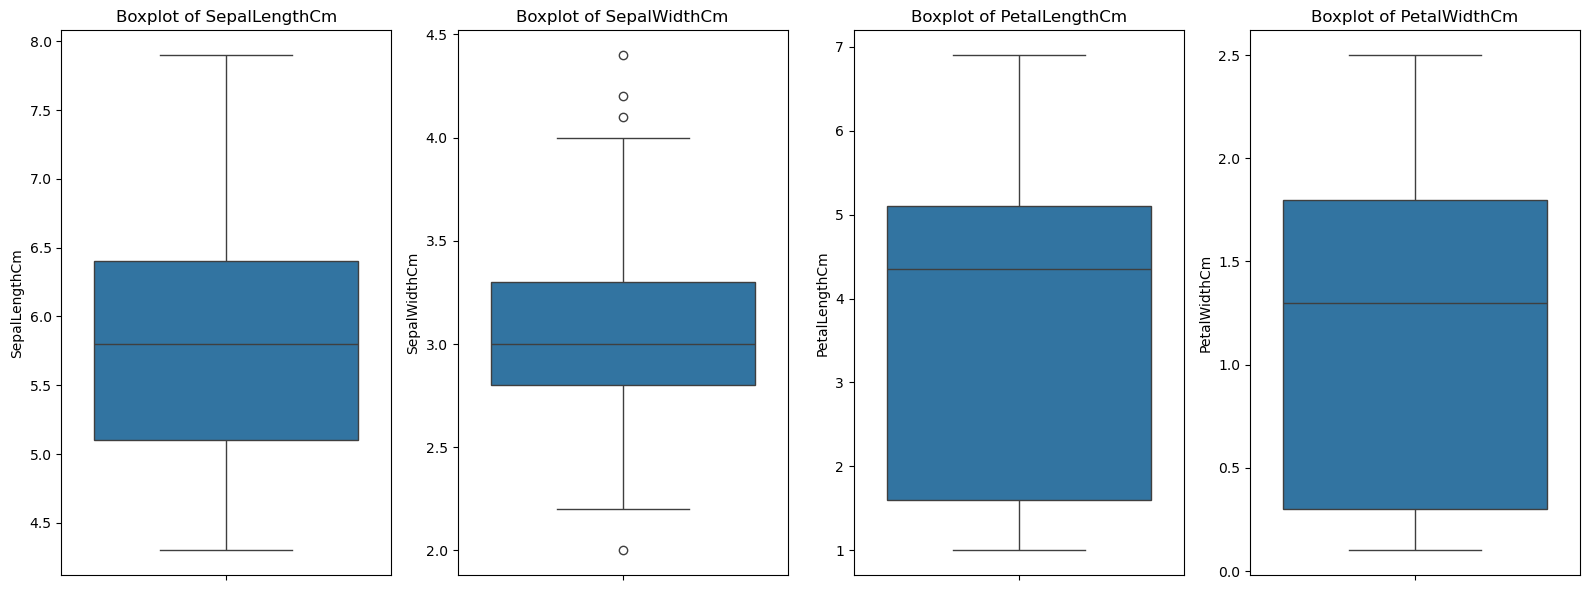

In [9]:
#check the outlieres 
# List of numeric columns to visualize
columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Set up the figure and axes
plt.figure(figsize=(16, 6))
for i, col in enumerate(columns, 1):
    plt.subplot(1, len(columns), i)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

In [10]:
#removing outliers in sepal width column to help in machine learning process
q1=df['SepalWidthCm'].quantile(0.25)
q3=df['SepalWidthCm'].quantile(0.75)
IQR=q3-q1
lower=q1-1.5*IQR
upper=q3+1.5*IQR
df=df[(df['SepalWidthCm']>=lower)&(df['SepalWidthCm']<=upper)]

In [13]:
#check removing outliers
len(df)

146

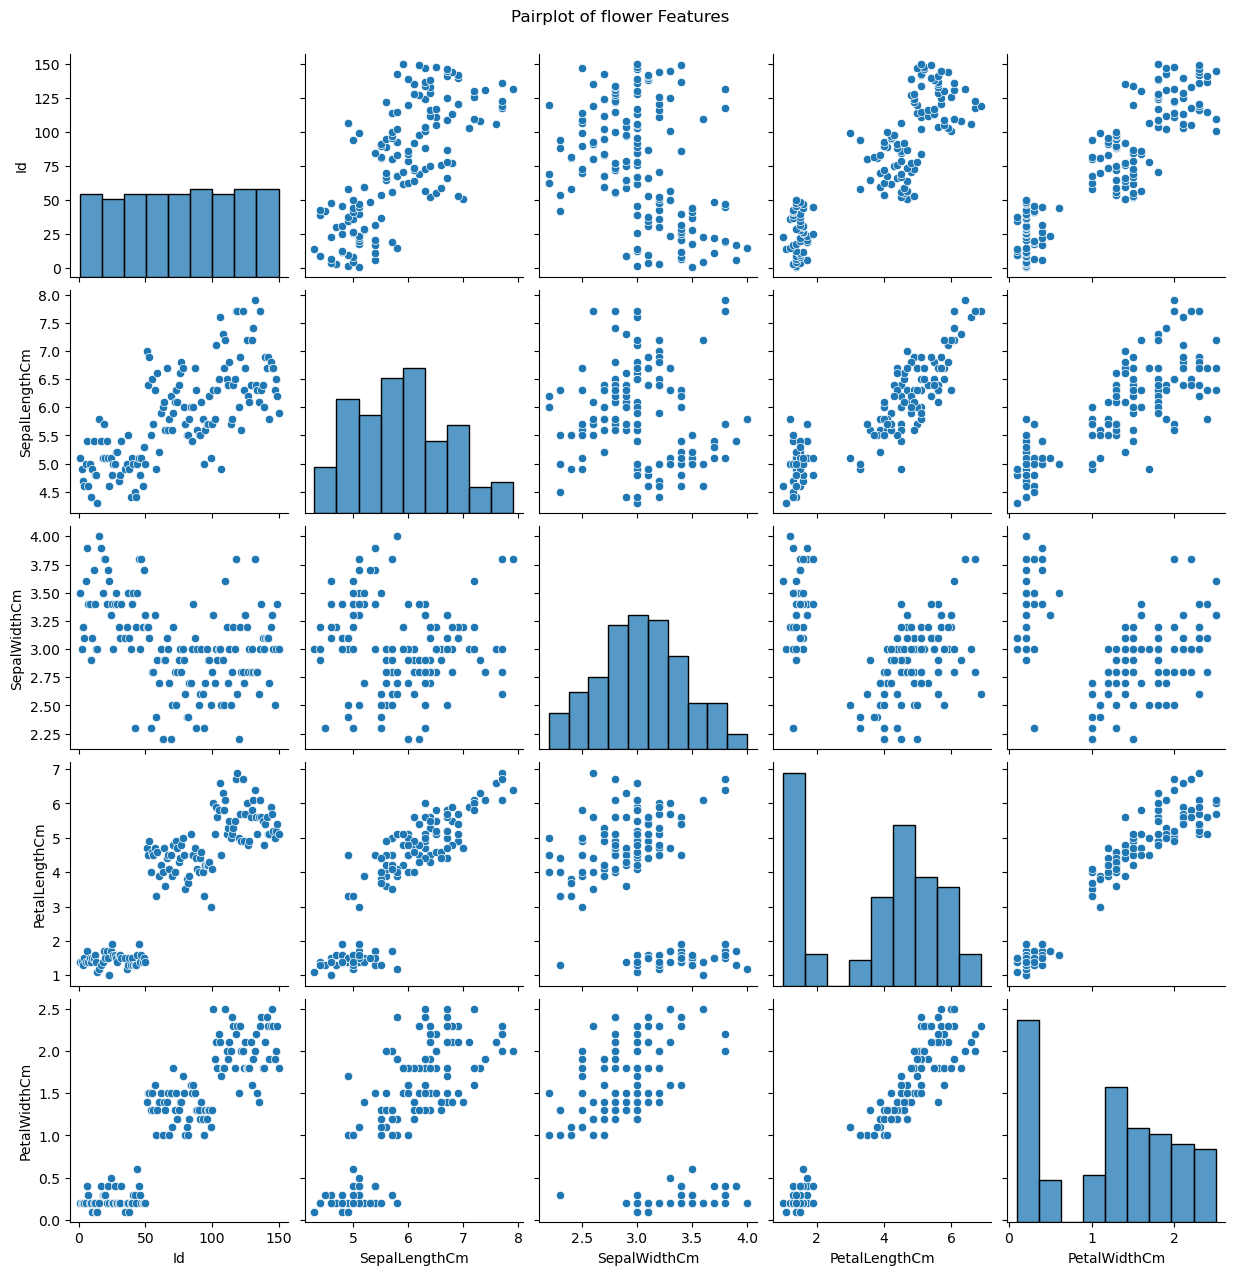

In [14]:
#now we have clean df  with no duplicates ,no nulls ,no outliers 
# exploratory data analysis 
sns.pairplot(df)
plt.suptitle("Pairplot of flower Features", y=1.02)
plt.show()

In [22]:
#features
X=df.drop(columns=['Id','Species'])
#target 
Y=df['Species']

In [23]:
#slicing the data  
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)

In [32]:
#training the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [37]:
#model accuracy result

Y_pred = model.predict(X_test)

In [41]:
accuracy=accuracy_score(Y_test,Y_pred)
print("accuracy:" ,accuracy)

accuracy: 0.9333333333333333


In [42]:
print('confusion matrix:',confusion_matrix(Y_test,Y_pred))

confusion matrix: [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [45]:
print('classification report:',classification_report(Y_test,Y_pred))

classification report:                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30




Precision: How many of the predicted samples for a class were actually correct.
Recall: How many of the actual samples of a class were correctly identified.
F1-score: The balance between precision and recall.
Accuracy (90%): The model correctly predicted 90% of all flower species in the test dataset


#conclusion:
the Iris flower measurements (Sepal Length, Sepal Width, Petal Length, and Petal Width) were used to predict the species of the flowers. The Random Forest Classifier achieved an accuracy of 90% on the test data, which indicates good performance. The model classified Iris-setosa perfectly with 100% precision and recall. However, there were a few misclassifications between Iris-versicolor and Iris-virginica because these two species have similar characteristics and overlapping features.
